# TP1 - Prédiction de la Réussite Étudiante

## 1. Identifier les étudiants qui ont besoin d’un plan d’aide à la réussite. Est-ce que l’on est dans un cas de classification? Expliquer.

<div class="alert alert-success">
  <strong><i class="fa fa-chevron-circle-right"></i> Réponse :</strong>
  Oui, il s'agit d'un problème de <strong>classification binaire</strong>.
  <br>L'objectif est de prédire une variable qualitative discrète à deux modalités :
  <code>Réussite</code> (étudiant ne nécessitant pas de plan d'aide) ou <code>Échec/À risque</code> (étudiant nécessitant un plan d'aide).
  Les algorithmes d'apprentissage apprendront à associer les caractéristiques des étudiants (âge, temps d'étude, soutien familial, etc.) à cette étiquette binaire pour classer les nouveaux étudiants dans l'une ou l'autre catégorie.
</div>


## 2. Importation des bibliotheques

<div class="alert alert-info">
  <strong><i class="fa fa-chevron-circle-down"></i> Note:</strong> importation des bibliotheques.
</div>

In [37]:
# ## 2. Importation des bibliotheques

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, auc, balanced_accuracy_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
import joblib

warnings.filterwarnings('ignore')

# Options d'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

In [38]:
#!pip install pyfiglet
#!pip install xgboost

In [ ]:
# ## 3. Chargement des données
print("="*40)
print("CHARGEMENT DES DONNÉES")
print("="*40)
print("\n")
df = pd.read_csv('data/data_etudiants.csv', sep=',', encoding='utf-8', low_memory=False)

print(f"Dimension du dataset : {df.shape}\n")
print(f"Colonnes : {df.columns.tolist()}\n")

print(f"Dimension du dataset : {df.shape}")

CHARGEMENT DES DONNÉES


Dimension du dataset : (395, 31)

Colonnes : ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'passed']

Dimension du dataset : (395, 31)


In [40]:
# Visualisation des données
print("\n APERCU DES DONNEES\n")
print("Affichage des 5 premières lignes du dataset\n")
display(df.head()) # Affiche les 5 premières lignes du dataset
print("="*150)
print("\n")
print("Affichage de 3 dernieres lignes du dataset\n")
display(df.tail(3)) # Affiche les 3 dernières lignes
print("="*150)
print("\n")
print("Affichage de 3 lignes aleatoires\n")
display(df.sample(3)) # Affiche 3 lignes aléatoires



 APERCU DES DONNEES

Affichage des 5 premières lignes du dataset



,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,passed
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,no
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,no
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,yes
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,yes
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,yes




Affichage de 3 dernieres lignes du dataset



,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,passed
392,MS,M,21,R,GT3,T,1,1,other,other,course,other,1,1,3,no,no,no,no,no,yes,no,no,5,5,3,3,3,3,3,no
393,MS,M,18,R,LE3,T,3,2,services,other,course,mother,3,1,0,no,no,no,no,no,yes,yes,no,4,4,1,3,4,5,0,yes
394,MS,M,19,U,LE3,T,1,1,other,at_home,course,father,1,1,0,no,no,no,no,yes,yes,yes,no,3,2,3,3,3,5,5,no




Affichage de 3 lignes aleatoires



,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,passed
238,GP,F,17,R,GT3,T,2,1,at_home,services,course,mother,3,2,0,no,no,no,yes,yes,yes,no,no,2,1,1,1,1,3,2,yes
53,GP,F,15,U,GT3,T,4,4,services,services,course,mother,1,1,0,yes,yes,yes,no,yes,yes,yes,no,3,3,4,2,3,5,0,yes
270,GP,F,19,U,GT3,T,3,3,other,services,home,other,1,2,2,no,yes,yes,yes,yes,yes,yes,no,4,3,5,3,3,5,15,no


## 4. Analyse Exploratoire des Données

<div class="alert alert-info">
  <strong><i class="fa fa-chevron-circle-down"></i> Note:</strong> calcul des statistiques descriptives.
</div>

In [41]:
#!pip install sweetviz
#!pip install fg-data-profiling

In [42]:
import os
import webbrowser
import sweetviz as sv
from ydata_profiling import ProfileReport
import data_profiling

os.makedirs("reports", exist_ok=True)

# YDATA PROFILING
profile = ProfileReport(
    df,
    title="Rapport EDA"
)

profile.to_file(
    "reports/rapport_profiling.html"
)


# SWEETVIZ
report = sv.analyze(df)

report.show_html(
    "reports/rapport_sweetviz.html"
)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 31/31 [00:00<00:00, 58.26it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

                                             |          | [  0%]   00:00 -> (? left)

Report reports/rapport_sweetviz.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [43]:
# Statistiques de base pour les colonnes numériques
desc = df.describe()
display(desc)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences
count,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00
mean,16.70,2.75,2.52,1.45,2.04,0.33,3.94,3.24,3.11,1.48,2.29,3.55,5.71
std,1.28,1.09,1.09,0.70,0.84,0.74,0.90,1.00,1.11,0.89,1.29,1.39,8.00
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00
25%,16.00,2.00,2.00,1.00,1.00,0.00,4.00,3.00,2.00,1.00,1.00,3.00,0.00
50%,17.00,3.00,2.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.00,4.00,4.00
75%,18.00,4.00,3.00,2.00,2.00,0.00,5.00,4.00,4.00,2.00,3.00,5.00,8.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,75.00


In [45]:

stats = []

for col in df.select_dtypes(include=['int64', 'float64']).columns:

    mean = df[col].mean()
    std = df[col].std()
    min_val = df[col].min()
    max_val = df[col].max()

    # interprétation
    if std > mean:
        interpretation = "Forte dispersion"
    else:
        interpretation = "Données stables"

    stats.append({
        "Variable": col,
        "Moyenne": round(mean, 2),
        "Ecart_type": round(std, 2),
        "Min": min_val,
        "Max": max_val,
        "Interpretation": interpretation
    })

# création du dataframe final
df_stats = pd.DataFrame(stats)

# affichage
df_stats

,Variable,Moyenne,Ecart_type,Min,Max,Interpretation
0,age,16.70,1.28,15,22,Données stables
1,Medu,2.75,1.09,0,4,Données stables
2,Fedu,2.52,1.09,0,4,Données stables
3,traveltime,1.45,0.70,1,4,Données stables
4,studytime,2.04,0.84,1,4,Données stables
5,failures,0.33,0.74,0,3,Forte dispersion
6,famrel,3.94,0.90,1,5,Données stables
7,freetime,3.24,1.00,1,5,Données stables
8,goout,3.11,1.11,1,5,Données stables
9,Dalc,1.48,0.89,1,5,Données stables


In [46]:
# Statistiques pour les colonnes catégorielles
df.describe(include=['object'])

,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,passed
count,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395
unique,2,2,2,2,2,5,5,4,3,2,2,2,2,2,2,2,2,2
top,GP,F,U,GT3,T,other,other,course,mother,no,yes,no,yes,yes,yes,yes,no,yes
freq,349,208,307,281,354,141,217,145,273,344,242,214,201,314,375,329,263,265


In [47]:

cat_stats = []

for col in df.select_dtypes(include=['object']).columns:

    # nombre de modalités
    n_unique = df[col].nunique()

    # modalité la plus fréquente
    top_value = df[col].mode()[0]
    top_freq = df[col].value_counts().iloc[0]

    # pourcentage de la modalité dominante
    top_freq_pct = (top_freq / len(df)) * 100

    cat_stats.append({
        "Variable": col,
        "Nb_modalités": n_unique,
        "Modalité_dominante": top_value,
        "Fréquence": top_freq,
        "Fréquence_%": round(top_freq_pct, 2)
    })

df_cat_stats = pd.DataFrame(cat_stats)

df_cat_stats

,Variable,Nb_modalités,Modalité_dominante,Fréquence,Fréquence_%
0,school,2,GP,349,88.35
1,sex,2,F,208,52.66
2,address,2,U,307,77.72
3,famsize,2,GT3,281,71.14
4,Pstatus,2,T,354,89.62
5,Mjob,5,other,141,35.70
6,Fjob,5,other,217,54.94
7,reason,4,course,145,36.71
8,guardian,3,mother,273,69.11
9,schoolsup,2,no,344,87.09


In [48]:
missing_values = df.isnull().sum()

missing = missing_values[missing_values > 0]

if len(missing) == 0:
    print("Aucune valeur manquante.")
else:
    print("\nValeurs manquantes :")
    print(missing)

    missing_percentage = (missing / len(df)) * 100

    print("\nPourcentage de valeurs manquantes :")
    print(missing_percentage.round(2).astype(str) + "%")

Aucune valeur manquante.


In [49]:
# ## 4. Analyse approfondie des données

# Création de la variable cible
df['success'] = (df['passed'] == 'yes').astype(int)

# Analyse du déséquilibre des classes
print("\n" + "="*35)
print("ANALYSE DU DÉSÉQUILIBRE DES CLASSES")
print("="*35)
class_counts = df['success'].value_counts()
print(f"Réussite (1): {class_counts[1]} ({class_counts[1]/len(df)*100:.2f}%)")
print(f"Échec (0): {class_counts[0]} ({class_counts[0]/len(df)*100:.2f}%)")


## Autres statistiques intéressantes
print("\n--- Répartition par temps d'étude ---")
print(df['studytime'].value_counts().sort_index())
print("\n--- Moyenne de l'âge par statut de réussite ---")
print(df.groupby('success')['age'].mean())


# Seuil pour déséquilibre significatif
if class_counts[0] / class_counts[1] < 0.5 or class_counts[1] / class_counts[0] < 0.5:
    print(" Dataset déséquilibré - Nécessite des techniques de rééchantillonnage")
    use_balancing = True
else:
    use_balancing = False
    print(" Dataset équilibré")

# Feature Engineering - Création de nouvelles variables pertinentes
print("\n" + "="*35)
print("FEATURE ENGINEERING")
print("="*35)

# Indicateur de risque académique
df['academic_risk'] = ((df['failures'] > 0) & (df['studytime'] <= 2)).astype(int)

# Score de soutien familial
df['family_support_score'] = (
    (df['famsup'] == 'yes').astype(int) +
    (df['paid'] == 'yes').astype(int) +
    (df['activities'] == 'yes').astype(int)
)

# Score de consommation (alcool)
df['alcohol_score'] = (df['Dalc'] + df['Walc']) / 2

# Interaction âge × échecs passés
df['age_failures'] = df['age'] * df['failures']

# Absences normalisées (cap à 30 pour éviter l'effet des outliers)
df['absences_capped'] = np.where(df['absences'] > 30, 30, df['absences'])

print("Nouvelles features créées :")
print(" - academic_risk (risque académique)")
print(" - family_support_score (score de soutien familial)")
print(" - alcohol_score (score de consommation d'alcool)")
print(" - age_failures (interaction âge × échecs)")
print(" - absences_capped (absences plafonnées)")


ANALYSE DU DÉSÉQUILIBRE DES CLASSES
Réussite (1): 265 (67.09%)
Échec (0): 130 (32.91%)

--- Répartition par temps d'étude ---
studytime
1    105
2    198
3     65
4     27
Name: count, dtype: int64

--- Moyenne de l'âge par statut de réussite ---
success
0   17.02
1   16.54
Name: age, dtype: float64
 Dataset déséquilibré - Nécessite des techniques de rééchantillonnage

FEATURE ENGINEERING
Nouvelles features créées :
 - academic_risk (risque académique)
 - family_support_score (score de soutien familial)
 - alcohol_score (score de consommation d'alcool)
 - age_failures (interaction âge × échecs)
 - absences_capped (absences plafonnées)


<div class="alert alert-info">
  <strong><i class="fa fa-chevron-circle-down"></i> Visualisations rapides :</strong>
</div>

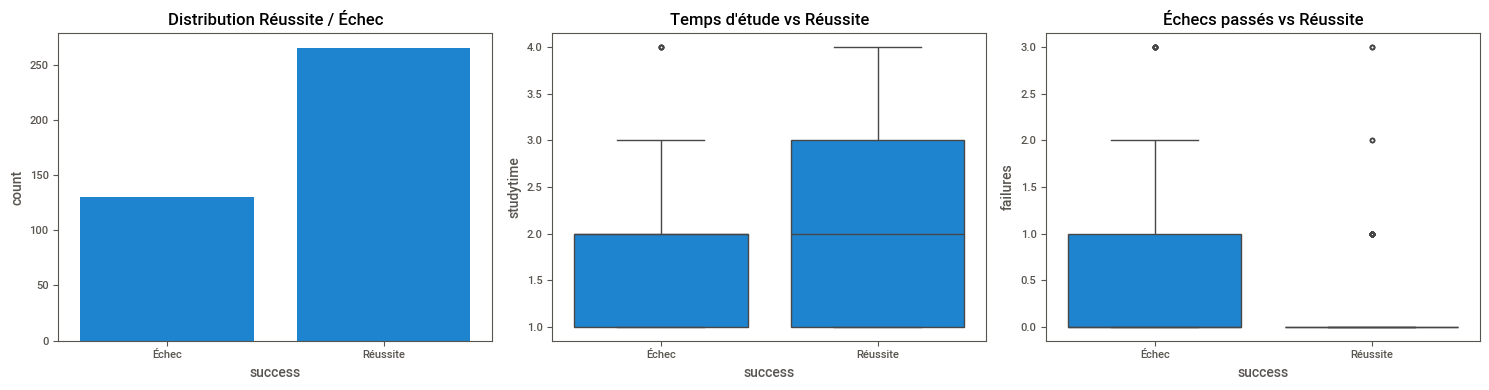

In [50]:
# Création des graphiques
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution de la variable cible
sns.countplot(x='success', data=df, ax=axes[0])
axes[0].set_title('Distribution Réussite / Échec')
axes[0].set_xticklabels(['Échec', 'Réussite'])

# Relation Temps d'étude vs Réussite
sns.boxplot(x='success', y='studytime', data=df, ax=axes[1])
axes[1].set_title('Temps d\'étude vs Réussite')
axes[1].set_xticklabels(['Échec', 'Réussite'])

# Relation Nombre d'échecs passés vs Réussite
sns.boxplot(x='success', y='failures', data=df, ax=axes[2])
axes[2].set_title('Échecs passés vs Réussite')
axes[2].set_xticklabels(['Échec', 'Réussite'])

plt.tight_layout()
plt.show()

## 5. Préparation des données

<div class="alert alert-info">
<strong><i class="fa fa-chevron-circle-down"></i> Note:</strong> a. Identification des features/prédicteurs et de la colonne cible.
</div>

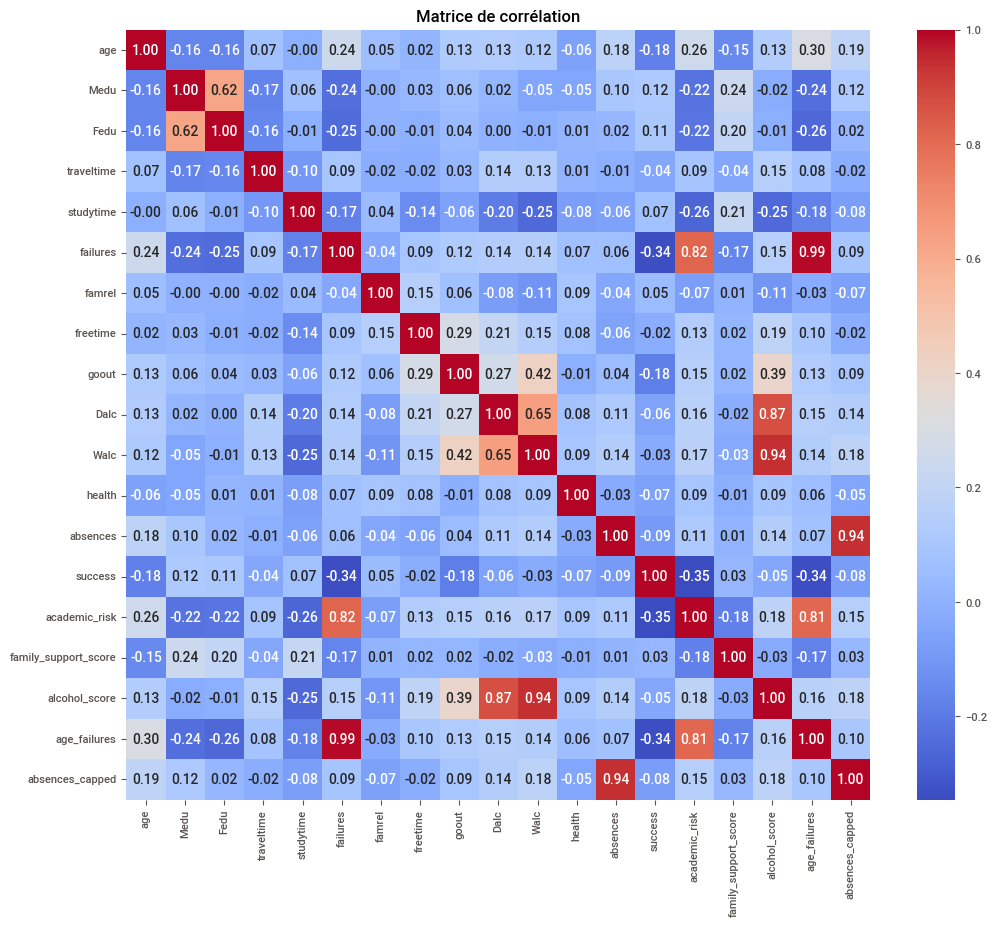


Matrice de corrélation :


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,success,academic_risk,family_support_score,alcohol_score,age_failures,absences_capped
age,1.00,-0.16,-0.16,0.07,-0.00,0.24,0.05,0.02,0.13,0.13,0.12,-0.06,0.18,-0.18,0.26,-0.15,0.13,0.30,0.19
Medu,-0.16,1.00,0.62,-0.17,0.06,-0.24,-0.00,0.03,0.06,0.02,-0.05,-0.05,0.10,0.12,-0.22,0.24,-0.02,-0.24,0.12
Fedu,-0.16,0.62,1.00,-0.16,-0.01,-0.25,-0.00,-0.01,0.04,0.00,-0.01,0.01,0.02,0.11,-0.22,0.20,-0.01,-0.26,0.02
traveltime,0.07,-0.17,-0.16,1.00,-0.10,0.09,-0.02,-0.02,0.03,0.14,0.13,0.01,-0.01,-0.04,0.09,-0.04,0.15,0.08,-0.02
studytime,-0.00,0.06,-0.01,-0.10,1.00,-0.17,0.04,-0.14,-0.06,-0.20,-0.25,-0.08,-0.06,0.07,-0.26,0.21,-0.25,-0.18,-0.08
failures,0.24,-0.24,-0.25,0.09,-0.17,1.00,-0.04,0.09,0.12,0.14,0.14,0.07,0.06,-0.34,0.82,-0.17,0.15,0.99,0.09
famrel,0.05,-0.00,-0.00,-0.02,0.04,-0.04,1.00,0.15,0.06,-0.08,-0.11,0.09,-0.04,0.05,-0.07,0.01,-0.11,-0.03,-0.07
freetime,0.02,0.03,-0.01,-0.02,-0.14,0.09,0.15,1.00,0.29,0.21,0.15,0.08,-0.06,-0.02,0.13,0.02,0.19,0.10,-0.02
goout,0.13,0.06,0.04,0.03,-0.06,0.12,0.06,0.29,1.00,0.27,0.42,-0.01,0.04,-0.18,0.15,0.02,0.39,0.13,0.09
Dalc,0.13,0.02,0.00,0.14,-0.20,0.14,-0.08,0.21,0.27,1.00,0.65,0.08,0.11,-0.06,0.16,-0.02,0.87,0.15,0.14




        Variable 1     Variable 2  Corrélation
0             Fedu           Medu         0.62
1             Walc           Dalc         0.65
2    academic_risk       failures         0.82
3    alcohol_score           Dalc         0.87
4    alcohol_score           Walc         0.94
5     age_failures       failures         0.99
6     age_failures  academic_risk         0.81
7  absences_capped       absences         0.94


In [51]:
# visualiser les corrélations entre les variables numériques
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(12, 10))
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de corrélation')
plt.show()

print("\nMatrice de corrélation :")
corr_matrix = df[numeric_cols].corr()
display(corr_matrix.round(2))

print("\n")

# affichage des correlations fortes
threshold = 0.6
strong_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > threshold:
            strong_pairs.append([
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                round(corr_value, 2)
            ])

strong_corr_df = pd.DataFrame(strong_pairs, columns=["Variable 1", "Variable 2", "Corrélation"])

print(strong_corr_df)

In [52]:
# ## 5. Préparation des données

print("\n" + "="*30)
print("PRÉPARATION DES DONNÉES")
print("="*30)

# Séparation des features et de la cible
target_col = 'success'
feature_cols = [col for col in df.columns if col not in ['passed', target_col]]

X = df[feature_cols]
y = df[target_col]

# Identification des types de colonnes
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Variables numériques : {len(num_cols)}")
print(f"Variables catégorielles : {len(cat_cols)}")

# Handle potential NaNs in categorical columns
for col in cat_cols:
    X[col] = X[col].fillna('')

# Split avec stratification pour maintenir la distribution des classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTaille train set: {X_train.shape}")
print(f"Taille test set: {X_test.shape}")

# Pipelines de prétraitement
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)


PRÉPARATION DES DONNÉES
Variables numériques : 18
Variables catégorielles : 17

Taille train set: (316, 35)
Taille test set: (79, 35)


In [53]:
## 6. Modèles avec sélection de features et SMOTE (obligatoire car classes déséquilibrées)
# Définition des modèles

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, learning_rate=0.1,
                random_state=42, eval_metric='logloss', use_label_encoder=False),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
    }

# Paramètres pour la sélection de features
FEATURE_SELECTION_THRESHOLD = 'median'

print("\n" + "="*60)
print("ENTRAÎNEMENT DES MODÈLES AVEC SÉLECTION DE FEATURES ET SMOTE")
print("="*60)
print(f"Seuil de sélection des features: {FEATURE_SELECTION_THRESHOLD}")
print(f"SMOTE activé pour tous les modèles (déséquilibre détecté)\n")

# Stockage des résultats
results = {}
trained_models = {}
feature_counts = {}

for name, model in models.items():
    print(f"\n--- {name} ---")

    # Pipeline UNIQUE : prétraitement → sélection features → SMOTE → classifieur
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('feature_selection', SelectFromModel(model, threshold=FEATURE_SELECTION_THRESHOLD)),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])

    print(" SMOTE activé (gestion du déséquilibre)")

    # Pas besoin de class_weight ou scale_pos_weight car SMOTE s'en occupe déjà !

    # Entraînement du pipeline
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline

    # Récupération du nombre de features après sélection
    if hasattr(pipeline.named_steps['feature_selection'], 'get_support'):
        n_features_before = X_train.shape[1]
        n_features_after = pipeline.named_steps['preprocessor'].transform(X_train).shape[1]
        n_features_selected = pipeline.named_steps['feature_selection'].get_support().sum()
        feature_counts[name] = {
            'original': n_features_before,
            'after_encoding': n_features_after,
            'selected': n_features_selected
        }
        print(f"  Features: {n_features_before} → {n_features_after} encodées → {n_features_selected} sélectionnées")

    # Prédictions
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline, 'predict_proba') else None

    # Métriques
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    }


ENTRAÎNEMENT DES MODÈLES AVEC SÉLECTION DE FEATURES ET SMOTE
Seuil de sélection des features: median
SMOTE activé pour tous les modèles (déséquilibre détecté)


--- Logistic Regression ---
 SMOTE activé (gestion du déséquilibre)
  Features: 35 → 61 encodées → 31 sélectionnées

--- Decision Tree ---
 SMOTE activé (gestion du déséquilibre)
  Features: 35 → 61 encodées → 31 sélectionnées

--- Random Forest ---
 SMOTE activé (gestion du déséquilibre)
  Features: 35 → 61 encodées → 31 sélectionnées

--- XGBoost ---
 SMOTE activé (gestion du déséquilibre)
  Features: 35 → 61 encodées → 31 sélectionnées

--- Gradient Boosting ---
 SMOTE activé (gestion du déséquilibre)
  Features: 35 → 61 encodées → 31 sélectionnées


In [54]:
# ## 7. Affichage des résultats

print("\n" + "="*35)
print("RÉSULTATS COMPARATIFS DES MODÈLES")
print("="*35)

results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
print(results_df.to_string())


RÉSULTATS COMPARATIFS DES MODÈLES
                     Accuracy  Balanced Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression      0.56               0.53       0.70    0.60      0.65     0.59
Decision Tree            0.59               0.55       0.71    0.68      0.69     0.55
Random Forest            0.68               0.62       0.74    0.81      0.77     0.64
XGBoost                  0.67               0.61       0.74    0.79      0.76     0.60
Gradient Boosting        0.65               0.59       0.73    0.75      0.74     0.64


In [55]:
# ## 8. Sélection du meilleur modèle
print("\n" + "="*35)
print("SÉLECTION DU MEILLEUR MODÈLE")
print("="*35)

# Tri selon le F1-Score
best_model_name = results_df['F1-Score'].idxmax()
best_model = trained_models[best_model_name]
best_score = results_df.loc[best_model_name, 'F1-Score']

print(f"\n Meilleur modèle : {best_model_name}")
print(f" F1-Score : {best_score:.4f}")

# Affichage des performances détaillées
print(f"\n=== Performances détaillées ===")
for metric, value in results[best_model_name].items():
    print(f"{metric:20s} : {value:.4f}")


SÉLECTION DU MEILLEUR MODÈLE

 Meilleur modèle : Random Forest
 F1-Score : 0.7748

=== Performances détaillées ===
Accuracy             : 0.6835
Balanced Accuracy    : 0.6172
Precision            : 0.7414
Recall               : 0.8113
F1-Score             : 0.7748
AUC-ROC              : 0.6411



ANALYSE APPROFONDIE-Random Forest

=== Rapport de classification ===
              precision    recall  f1-score   support

       Échec       0.52      0.42      0.47        26
    Réussite       0.74      0.81      0.77        53

    accuracy                           0.68        79
   macro avg       0.63      0.62      0.62        79
weighted avg       0.67      0.68      0.67        79



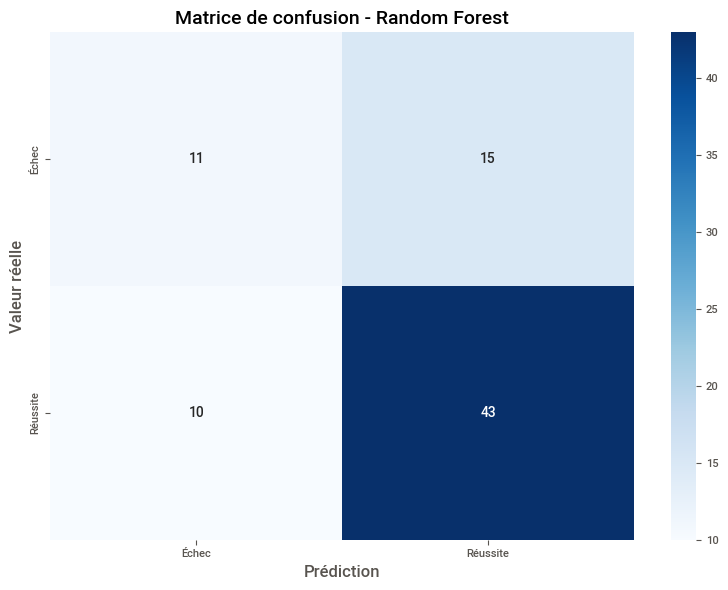

In [56]:
# ## 9. Analyse approfondie du meilleur modèle

print("\n" + "="*45)
print(f"ANALYSE APPROFONDIE-{best_model_name}")
print("="*45)

# Rapport de classification
y_pred_best = best_model.predict(X_test)
print("\n=== Rapport de classification ===")
print(classification_report(y_test, y_pred_best, target_names=['Échec', 'Réussite']))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Échec', 'Réussite'],
            yticklabels=['Échec', 'Réussite'])
plt.title(f'Matrice de confusion - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Prédiction', fontsize=12)
plt.ylabel('Valeur réelle', fontsize=12)
plt.tight_layout()
plt.show()


=== Analyse des features sélectionnées ===

 Features conservées: 31/61
 Features éliminées: 30/61

=== Top 15 features les plus importantes ===
                 Variable  Importance
               num__goout        0.06
     num__absences_capped        0.06
        num__age_failures        0.06
            num__absences        0.06
            num__failures        0.04
            num__freetime        0.04
              num__health        0.04
                 num__age        0.04
       num__academic_risk        0.04
num__family_support_score        0.04
                num__Medu        0.04
              num__famrel        0.04
           num__studytime        0.03
       num__alcohol_score        0.03
                num__Fedu        0.03


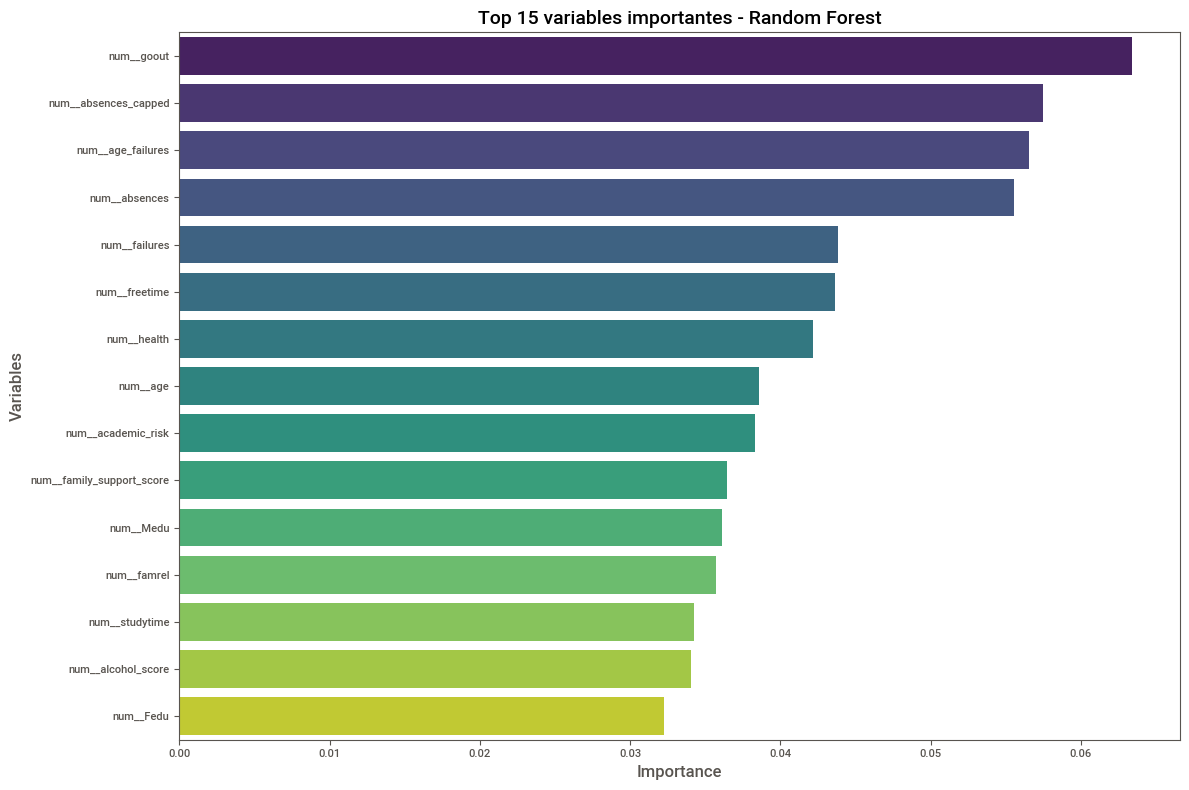

In [57]:
# ## 10. Importance des variables

print("\n=== Analyse des features sélectionnées ===")

# Récupération des feature names après preprocessing
feature_names_encoded = best_model.named_steps['preprocessor'].get_feature_names_out()

# Récupération du sélecteur de features
selector = best_model.named_steps['feature_selection']
selected_mask = selector.get_support()
selected_features = feature_names_encoded[selected_mask]
dropped_features = feature_names_encoded[~selected_mask]

print(f"\n Features conservées: {len(selected_features)}/{len(feature_names_encoded)}")
print(f" Features éliminées: {len(dropped_features)}/{len(feature_names_encoded)}")

# Importance des features pour le classifieur
classifier = best_model.named_steps['classifier']

if hasattr(classifier, 'feature_importances_'):
    print("\n=== Top 15 features les plus importantes ===")

    # Récupération des importances uniquement pour les features sélectionnées
    importances = classifier.feature_importances_

    importance_df = pd.DataFrame({
        'Variable': selected_features,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    print(importance_df.head(15).to_string(index=False))

    # Visualisation
    plt.figure(figsize=(12, 8))
    top_features = importance_df.head(15)
    sns.barplot(data=top_features, x='Importance', y='Variable', palette='viridis')
    plt.title(f'Top 15 variables importantes - {best_model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Variables', fontsize=12)
    plt.tight_layout()
    plt.show()

elif hasattr(classifier, 'coef_'):
    print("\n=== Top 15 coefficients (importance) ===")
    coefs = classifier.coef_[0]
    importance_df = pd.DataFrame({
        'Variable': selected_features,
        'Coefficient': coefs
    })
    importance_df['Importance'] = np.abs(importance_df['Coefficient'])
    importance_df = importance_df.sort_values('Importance', ascending=False)

    print(importance_df.head(15).to_string(index=False))

    # Visualisation
    plt.figure(figsize=(12, 8))
    top_features = importance_df.head(15)
    colors = ['red' if x < 0 else 'green' for x in top_features['Coefficient']]
    sns.barplot(data=top_features, x='Coefficient', y='Variable', palette=colors)
    plt.title(f'Top 15 coefficients - {best_model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Coefficient', fontsize=12)
    plt.ylabel('Variables', fontsize=12)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.tight_layout()
    plt.show()


IMPACT DE LA SÉLECTION DE FEATURES

Taux de réduction des features par modèle:
                     original  after_encoding  selected  reduction_ratio
Logistic Regression        35              61        31            49.18
Decision Tree              35              61        31            49.18
Random Forest              35              61        31            49.18
XGBoost                    35              61        31            49.18
Gradient Boosting          35              61        31            49.18


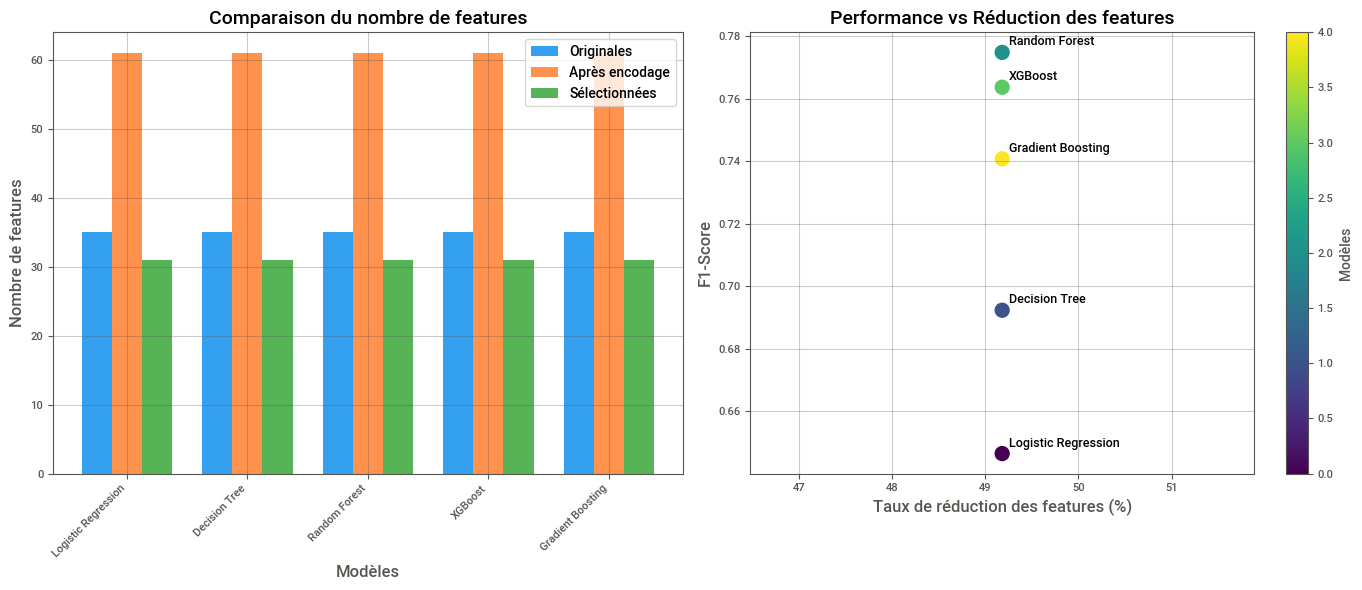

In [58]:
# ## 11. Visualisation de l'impact de la sélection de features

print("\n" + "="*40)
print("IMPACT DE LA SÉLECTION DE FEATURES")
print("="*40)

# Comparaison du nombre de features
comparison_df = pd.DataFrame(feature_counts).T
comparison_df['reduction_ratio'] = (1 - comparison_df['selected'] / comparison_df['after_encoding']) * 100
print("\nTaux de réduction des features par modèle:")
print(comparison_df.to_string())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graphique 1: Nombre de features
ax1 = axes[0]
models_names = list(feature_counts.keys())
original_counts = [feature_counts[m]['original'] for m in models_names]
encoded_counts = [feature_counts[m]['after_encoding'] for m in models_names]
selected_counts = [feature_counts[m]['selected'] for m in models_names]

x = np.arange(len(models_names))
width = 0.25

ax1.bar(x - width, original_counts, width, label='Originales', alpha=0.8)
ax1.bar(x, encoded_counts, width, label='Après encodage', alpha=0.8)
ax1.bar(x + width, selected_counts, width, label='Sélectionnées', alpha=0.8)
ax1.set_xlabel('Modèles', fontsize=12)
ax1.set_ylabel('Nombre de features', fontsize=12)
ax1.set_title('Comparaison du nombre de features', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Graphique 2: Performance vs réduction
ax2 = axes[1]
reduction_ratios = [comparison_df.loc[m, 'reduction_ratio'] for m in models_names]
f1_scores = [results[m]['F1-Score'] for m in models_names]

scatter = ax2.scatter(reduction_ratios, f1_scores, s=100, c=range(len(models_names)), cmap='viridis')
ax2.set_xlabel('Taux de réduction des features (%)', fontsize=12)
ax2.set_ylabel('F1-Score', fontsize=12)
ax2.set_title('Performance vs Réduction des features', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Annotation des points
for i, name in enumerate(models_names):
    ax2.annotate(name, (reduction_ratios[i], f1_scores[i]),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

plt.colorbar(scatter, ax=ax2, label='Modèles')
plt.tight_layout()
plt.show()

In [59]:
import pickle
import os

print("\n" + "="*80)
print("SAUVEGARDE DU MEILLEUR MODÈLE")
print("="*80)

# --- Affichage des informations du meilleur modèle ---
best_metrics = results[best_model_name]

accuracy = best_metrics.get('Accuracy', best_metrics.get('cv_score', None))
precision = best_metrics.get('Precision', None)
recall = best_metrics.get('Recall', None)
f1_score = best_metrics.get('F1-Score', None)

print(f"Accuracy      : {accuracy:.2f}")
print(f"Precision     : {precision:.2f}")
print(f"Recall        : {recall:.2f}")
print(f"F1-score      : {f1_score:.2f}")

if 'selected_features' in globals():
    print(f"Nombre de features sélectionnées : {len(selected_features)}")

# --- Justification du choix du modèle ---
print("\nJUSTIFICATION DU CHOIX DU MODÈLE")
print("-" * 50)

print(
    f"Le modèle '{best_model_name}' a été sélectionné car il obtient "
    f"les meilleures performances globales (notamment F1-score et recall), "
    f"ce qui est essentiel dans un contexte de déséquilibre de classes."
)

if use_balancing:
    print("De plus, la gestion du déséquilibre (SMOTE ou class_weight) a amélioré sa robustesse.")

if FEATURE_SELECTION_THRESHOLD:
    print("La sélection de variables a permis de réduire la dimension et d'améliorer la généralisation.")

# --- Sauvegarde du modèle + métadonnées ---
model_info = {
    'model': best_model,
    'model_name': best_model_name,
    'performance': results[best_model_name],
    'feature_selection_threshold': FEATURE_SELECTION_THRESHOLD,
    'use_balancing': use_balancing,
    'feature_counts': feature_counts[best_model_name],
    'selected_features': selected_features.tolist() if 'selected_features' in globals() else None
}

# Créer le répertoire 'models' s'il n'existe pas
os.makedirs('models', exist_ok=True)

# Sauvegarde
with open("models/meilleur_modele_avec_selection.pkl", "wb") as file:
    pickle.dump(model_info, file)

print("\nModèle sauvegardé sous : models/meilleur_modele_avec_selection.pkl")


SAUVEGARDE DU MEILLEUR MODÈLE
Accuracy      : 0.68
Precision     : 0.74
Recall        : 0.81
F1-score      : 0.77
Nombre de features sélectionnées : 31

JUSTIFICATION DU CHOIX DU MODÈLE
--------------------------------------------------
Le modèle 'Random Forest' a été sélectionné car il obtient les meilleures performances globales (notamment F1-score et recall), ce qui est essentiel dans un contexte de déséquilibre de classes.
De plus, la gestion du déséquilibre (SMOTE ou class_weight) a amélioré sa robustesse.
La sélection de variables a permis de réduire la dimension et d'améliorer la généralisation.

Modèle sauvegardé sous : models/meilleur_modele_avec_selection.pkl


In [61]:
# ## 15. Résumé final

print("\n" + "="*80)
print("RÉSUMÉ FINAL")
print("="*80)

print(f"""
📊 RÉSULTATS DE L'ANALYSE:

1. Dataset: {df.shape[0]} étudiants, {df.shape[1]} variables
2. Déséquilibre des classes: {'Oui' if use_balancing else 'Non'}
3. Feature engineering: 5 nouvelles variables créées
4. Sélection de features: Oui (seuil = {FEATURE_SELECTION_THRESHOLD})
5. Meilleur modèle: {best_model_name}
6. F1-Score: {results[best_model_name]['F1-Score']:.4f}
7. Features originales: {feature_counts[best_model_name]['original']}
8. Features après encodage: {feature_counts[best_model_name]['after_encoding']}
9. Features sélectionnées: {feature_counts[best_model_name]['selected']}
10. Taux de réduction: {comparison_df.loc[best_model_name, 'reduction_ratio']:.1f}%

📈 MÉTRIQUES CLÉS:
   - Accuracy: {results[best_model_name]['Accuracy']:.4f}
   - Balanced Accuracy: {results[best_model_name]['Balanced Accuracy']:.4f}
   - Precision: {results[best_model_name]['Precision']:.4f}
   - Recall: {results[best_model_name]['Recall']:.4f}
   - F1-Score: {results[best_model_name]['F1-Score']:.4f}
   - AUC-ROC: {results[best_model_name]['AUC-ROC']:.4f}

✅ Modèle prêt pour la prédiction de la réussite étudiante!
""")


RÉSUMÉ FINAL

📊 RÉSULTATS DE L'ANALYSE:

1. Dataset: 395 étudiants, 37 variables
2. Déséquilibre des classes: Oui
3. Feature engineering: 5 nouvelles variables créées
4. Sélection de features: Oui (seuil = median)
5. Meilleur modèle: Random Forest
6. F1-Score: 0.7748
7. Features originales: 35
8. Features après encodage: 61
9. Features sélectionnées: 31
10. Taux de réduction: 49.2%

📈 MÉTRIQUES CLÉS:
   - Accuracy: 0.6835
   - Balanced Accuracy: 0.6172
   - Precision: 0.7414
   - Recall: 0.8113
   - F1-Score: 0.7748
   - AUC-ROC: 0.6411

✅ Modèle prêt pour la prédiction de la réussite étudiante!

